In [2]:
import os
import ast
import json
import pickle
import warnings
import numpy as np
import pandas as pd
import xarray as xr
import proplot as pplt
warnings.filterwarnings('ignore')
pplt.rc.update({
    'savefig.dpi':900,
    'savefig.bbox':'tight',
    'savefig.pad_inches':0.02,
    'tick.minor':False,
    'font.size':9,
    'label.size':9,
    'tick.labelsize':9,
    'title.size':9,
    'abc.size':9,
    'legend.fontsize':9,
    'suptitle.size':9,
    'leftlabelsize':9,
    'toplabelsize':9,
    'leftlabel.weight':'normal',
    'toplabel.weight':'normal',
    'reso':'xx-hi'})

In [3]:
with open('../scripts/configs.json', 'r', encoding='utf-8') as f:
    CONFIGS = json.load(f)
SPLITSDIR  = CONFIGS['filepaths']['splits']
WEIGHTSDIR = CONFIGS['filepaths']['weights']
PREDSDIR   = CONFIGS['filepaths']['predictions']
MODELSDIR  = CONFIGS['filepaths']['models']
MODELS     = CONFIGS['experiments']
SPLIT      = 'test'

# SR-gauss fieldvars are kernel-integrated; SR-BL uses direct bl
SR_GAUSS_FIELDVARS = MODELS['sr']['runs']['sr_gauss']['fieldvars']  # ['rh','thetae','thetaestar']
NN_SEEDS           = MODELS['nn']['seeds']                           # seeds for kernel weight averaging

COLORS = {}
LABELS = {}
for name, cfg in MODELS['nn']['runs'].items():
    COLORS[name] = cfg['color']
for name, cfg in MODELS['sr']['optimizedeqs'].items():
    COLORS[name] = cfg['color']
    LABELS[name] = cfg['description']

MINSAMP = 30   # minimum samples per bin
NBINS   = 40   # 1-D bin count

In [4]:
# ── Stats ─────────────────────────────────────────────────────────────────────
with open(os.path.join(SPLITSDIR, 'stats.json'), 'r', encoding='utf-8') as f:
    STATS = json.load(f)
tp_mean = float(STATS['tp_mean'])
tp_std  = float(STATS['tp_std'])

# ── Normalised test split ──────────────────────────────────────────────────────
with xr.open_dataset(os.path.join(SPLITSDIR, f'norm_{SPLIT}.h5'), engine='h5netcdf') as _ds:
    ntime = _ds.sizes['time']; nlat = _ds.sizes['lat']; nlon = _ds.sizes['lon']
    nsig  = _ds.sizes.get('sig', 1)
    refshape = (ntime, nlat, nlon)

    lats = _ds.lat.values; lons = _ds.lon.values
    dsig = _ds['dsig'].values                                   # (nsig,)

    levmin, levmax = CONFIGS['domain']['levrange']
    # Prefer actual sigma coordinate over linspace to match 0_weights.ipynb
    sig_coords = (_ds.coords['sig'].values if 'sig' in _ds.coords
                  else np.linspace(levmin/1000, levmax/1000, nsig))

    # Field stacks for kernel integration (nsamples, nfieldvars, nsig)
    _farrs = [_ds[v].transpose('time','lat','lon','sig').values.reshape(-1, nsig)
              for v in SR_GAUSS_FIELDVARS]
    fieldstack  = np.stack(_farrs, axis=1)
    surfmask    = (_ds['surfmask'].transpose('time','lat','lon','sig').values.reshape(-1, nsig)
                   if 'surfmask' in _ds else None)

    def _ravel(da):
        """Ravel a DataArray to (ntime*nlat*nlon,), tiling if no time dim."""
        if 'time' in da.dims:
            return da.transpose('time','lat','lon').values.ravel()
        return np.tile(da.values, (ntime, 1, 1)).ravel()

    lf_norm  = _ravel(_ds['lf'])  if 'lf'  in _ds else None
    shf_norm = _ravel(_ds['shf']) if 'shf' in _ds else None
    lhf_norm = _ravel(_ds['lhf']) if 'lhf' in _ds else None

    if 'bl' in _ds:
        _bl = _ds['bl']
        bl_norm = (_ravel(_bl.mean('sig')) if 'sig' in _bl.dims else _ravel(_bl))
    else:
        bl_norm = None

# ── Kernel integration (matching train.py) ────────────────────────────────────
def kernel_integrate(fields, weights, dsig, mask=None):
    w = fields * weights[None, :, :] * dsig[None, None, :]
    if mask is not None:
        w = w * mask[:, None, :]
    return w.sum(axis=2)                                        # (N, nfieldvars)

# Load NN-GAUSS kernel weights — also pull actual sig coordinate if stored in weights file
_kw_list = []
for _seed in NN_SEEDS:
    _wpath = os.path.join(WEIGHTSDIR, f'nn_gauss_{_seed}_weights.nc')
    if os.path.exists(_wpath):
        with xr.open_dataset(_wpath, engine='h5netcdf') as _wds:
            _kw_list.append(_wds['k'].values)                   # (nfieldvars, nsig)
            if 'sig' in _wds.coords and len(_kw_list) == 1:
                sig_coords = _wds.coords['sig'].values          # authoritative sigma levels

if _kw_list:
    avg_kernel = np.mean(_kw_list, axis=0)                      # (nfieldvars, nsig) — for plotting
    _ki = np.mean([kernel_integrate(fieldstack, kw, dsig, surfmask) for kw in _kw_list], axis=0)
    rh_k         = _ki[:, 0]
    thetae_k     = _ki[:, 1]
    thetaestar_k = _ki[:, 2]
    print(f'Kernel weights: {len(_kw_list)}/{len(NN_SEEDS)} seeds loaded')
else:
    avg_kernel   = None
    rh_k         = fieldstack[:, 0, :].mean(axis=1)
    thetae_k     = fieldstack[:, 1, :].mean(axis=1)
    thetaestar_k = fieldstack[:, 2, :].mean(axis=1)
    print('Warning: no kernel weights found, falling back to vertical mean')

# ── Native test split (true precip + land mask) ───────────────────────────────
with xr.open_dataset(os.path.join(SPLITSDIR, f'{SPLIT}.h5'), engine='h5netcdf') as _ds:
    true_flat = _ds.tp.transpose('time','lat','lon').values.ravel()
    if 'lf' in _ds:
        _lf2d       = _ds['lf'].squeeze() if 'time' not in _ds['lf'].dims else _ds['lf'].isel(time=0)
        land_mask_2d = (_lf2d.values >= 0.5)
        land_flat    = np.broadcast_to(land_mask_2d[None], refshape).ravel().copy()
    else:
        land_mask_2d = land_flat = None

# ── SR registry ────────────────────────────────────────────────────────────────
_regpath = os.path.join(MODELSDIR, 'sr', 'optimized_equations.pkl')
if os.path.exists(_regpath):
    with open(_regpath, 'rb') as _f:
        SR_REGISTRY = pickle.load(_f)
    print(f'SR registry: {list(SR_REGISTRY.keys())}')
else:
    SR_REGISTRY = {}
    print('Warning: SR registry not found')


valid = (np.isfinite(true_flat) & np.isfinite(rh_k) &
         np.isfinite(thetae_k) & np.isfinite(thetaestar_k))
print(f'Valid samples: {valid.sum():,}')

Kernel weights: 3/3 seeds loaded
SR registry: ['sr_bl', 'sr_lo', 'sr_med', 'sr_hi']
Valid samples: 1,437,408


In [5]:
SRFUNCTIONS = {
    'cube':lambda x:x**3, 'square':lambda x:x**2, 'neg':lambda x:-x,
    'sqrt':np.sqrt, 'exp':np.exp, 'log':np.log, 'abs':np.abs,
    'sin':np.sin, 'cos':np.cos, 'max':np.maximum, 'min':np.minimum}

def to_phys(sr_out):
    """SR latent output → physical precipitation (mm / 3 h)"""
    return np.expm1(tp_std * np.maximum(0.0, np.asarray(sr_out, dtype=float)))

def eval_sr(name, var_dict):
    """Evaluate SR equation and return physical precipitation array."""
    if name not in SR_REGISTRY:
        return None
    entry = SR_REGISTRY[name]
    ns    = dict(SRFUNCTIONS, __builtins__={})
    ns.update(entry['constants'])
    ns.update(var_dict)
    out = eval(entry['form'], ns)
    if np.ndim(out) == 0:
        n   = next((len(v) for v in var_dict.values() if hasattr(v, '__len__')), 1)
        out = np.full(n, float(out))
    return to_phys(np.asarray(out, dtype=float))

def bin1d(x, z, nbins=NBINS, minsamp=MINSAMP, plo=1, phi=99):
    """1-D conditional mean of z given x; returns (edges, centers, means, counts)."""
    finite = np.isfinite(x) & np.isfinite(z)
    x, z   = x[finite], z[finite]
    edges  = np.unique(np.percentile(x, np.linspace(plo, phi, nbins + 1)))
    n      = len(edges) - 1
    xi     = np.clip(np.digitize(x, edges) - 1, 0, n - 1)
    means  = np.full(n, np.nan); counts = np.zeros(n, int)
    for i in range(n):
        sel = xi == i; counts[i] = sel.sum()
        if counts[i] >= minsamp: means[i] = z[sel].mean()
    return edges, 0.5*(edges[:-1]+edges[1:]), means, counts

def bin2d(x, y, z, xedges, yedges, minsamp=MINSAMP):
    """Fast 2-D binned mean of z; returns (means [ny,nx], counts)."""
    finite  = np.isfinite(x) & np.isfinite(y) & np.isfinite(z)
    x, y, z = x[finite], y[finite], z[finite]
    nx, ny  = len(xedges)-1, len(yedges)-1
    xi = np.clip(np.digitize(x, xedges)-1, 0, nx-1)
    yi = np.clip(np.digitize(y, yedges)-1, 0, ny-1)
    idx    = yi*nx + xi
    counts = np.bincount(idx, minlength=nx*ny).reshape(ny, nx)
    sums   = np.bincount(idx, weights=z, minlength=nx*ny).reshape(ny, nx)
    return np.where(counts >= minsamp, sums/counts, np.nan), counts

def prange(arr, lo=1, hi=99):
    """Percentile range of finite values."""
    a = arr[np.isfinite(arr)]
    return float(np.percentile(a, lo)), float(np.percentile(a, hi))

In [6]:
# ── SR-MED regime statistics ──────────────────────────────────────────────────
if 'sr_med' in SR_REGISTRY:
    _c = SR_REGISTRY['sr_med']['constants']
    a_m, b_m, c_m = _c['a'], _c['b'], _c['c']
    M_all = rh_k[valid]; I_all = thetae_k[valid] - b_m*thetaestar_k[valid] - c_m
    P_all = true_flat[valid]
    moist = M_all >= I_all; insta = ~moist
    print('SR-MED regimes (test set):')
    print(f'  Moisture-controlled (M≥I): {100*moist.mean():.1f}%  mean P={P_all[moist].mean():.3f} mm')
    print(f'  Instability-ctrl   (I>M):  {100*insta.mean():.1f}%  mean P={P_all[insta].mean():.3f} mm')
    if land_flat is not None:
        lv = land_flat[valid].astype(bool)
        for lbl, lmask in [('Land', lv), ('Ocean', ~lv)]:
            for rlbl, rmask in [('Moisture', moist), ('Instability', insta)]:
                m = lmask & rmask
                print(f'    {lbl:<5} {rlbl:<12}: {100*m.sum()/lmask.sum():.1f}%  mean P={P_all[m].mean():.3f}')

# ── SHF correlations ───────────────────────────────────────────────────────────
if shf_norm is not None:
    print('\nCorrelations with standardised SHF:')
    for lbl, arr in [('LHF~',lhf_norm),('LF~',lf_norm),('RH_hat',rh_k),('θe_hat',thetae_k),('Precip',true_flat)]:
        if arr is not None:
            r = np.corrcoef(shf_norm[valid], arr[valid])[0,1]
            print(f'  r(SHF, {lbl:10s}) = {r:+.3f}')
    if lhf_norm is not None:
        bowen = shf_norm[valid] / (lhf_norm[valid] + 1e-6)
        print(f'\n  High-SHF samples (top 25%):')
        shf_hi = shf_norm[valid] >= np.percentile(shf_norm[valid], 75)
        print(f'    mean LHF~={lhf_norm[valid][shf_hi].mean():.3f}  mean RH_hat={rh_k[valid][shf_hi].mean():.3f}  mean P={P_all[shf_hi].mean():.3f}')
        if land_flat is not None:
            lv = land_flat[valid].astype(bool)
            for lbl, lmask in [('Land',lv),('Ocean',~lv)]:
                m = lmask & shf_hi
                if m.sum() > 0:
                    print(f'    {lbl}: mean P={P_all[m].mean():.3f}  mean SHF~={shf_norm[valid][m].mean():.3f}')

SR-MED regimes (test set):
  Moisture-controlled (M≥I): 24.7%  mean P=1.079 mm
  Instability-ctrl   (I>M):  75.3%  mean P=0.668 mm
    Land  Moisture    : 37.8%  mean P=1.398
    Land  Instability : 62.2%  mean P=0.833
    Ocean Moisture    : 19.1%  mean P=0.812
    Ocean Instability : 80.9%  mean P=0.615

Correlations with standardised SHF:
  r(SHF, LHF~      ) = +0.267
  r(SHF, LF~       ) = -0.256
  r(SHF, RH_hat    ) = +0.025
  r(SHF, θe_hat    ) = -0.076
  r(SHF, Precip    ) = +0.008

  High-SHF samples (top 25%):
    mean LHF~=0.770  mean RH_hat=0.073  mean P=0.724
    Land: mean P=1.239  mean SHF~=0.620
    Ocean: mean P=0.076  mean SHF~=0.481


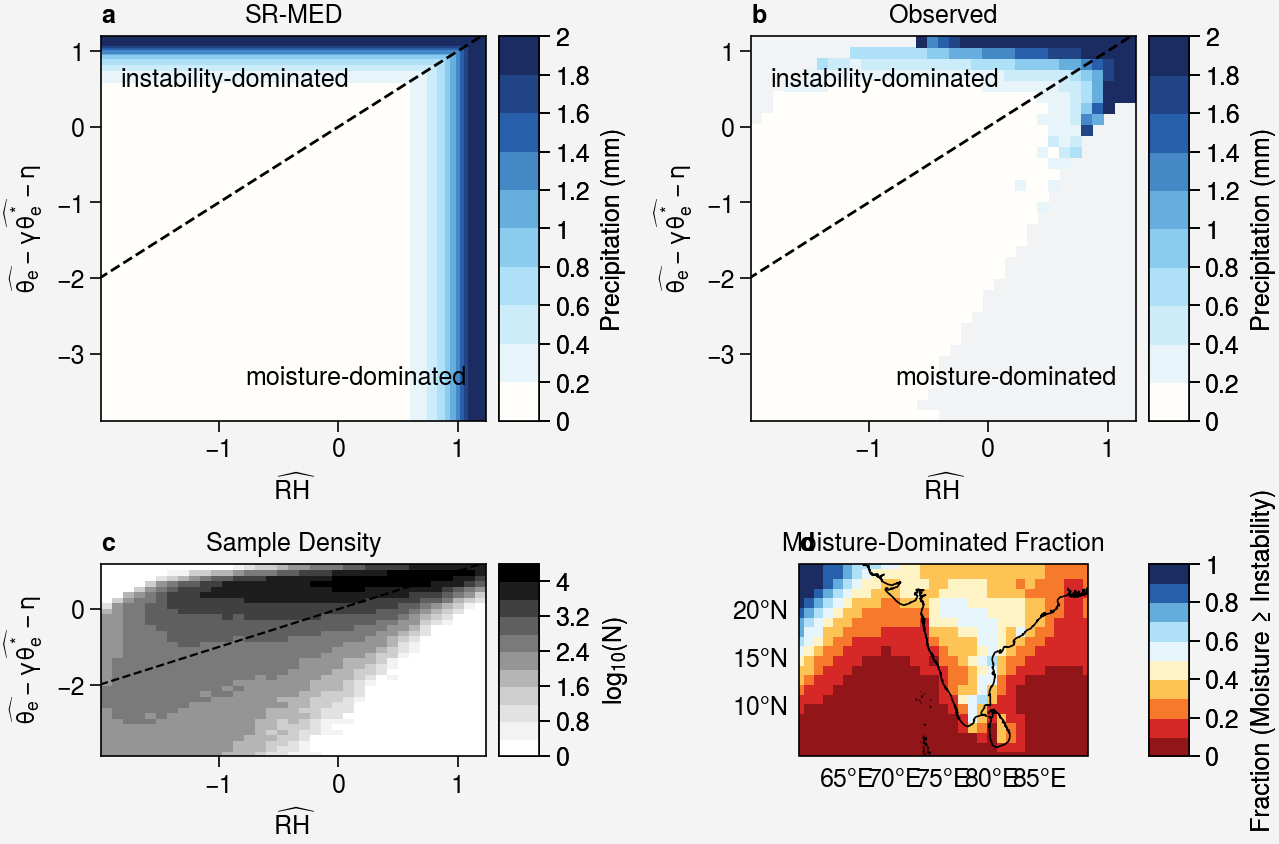

Moisture-ctrl: 24.7%  mean obs P=1.079 mm
Instability:   75.3%  mean obs P=0.668 mm


In [65]:
if 'sr_med' not in SR_REGISTRY:
    print('sr_med not in registry — skipping')
else:
    _c = SR_REGISTRY['sr_med']['constants']
    a_m, b_m, c_m = _c['a'], _c['b'], _c['c']
    M = rh_k[valid];  I = thetae_k[valid] - b_m*thetaestar_k[valid] - c_m
    P = true_flat[valid]
    M_lo, M_hi = prange(M);  I_lo, I_hi = prange(I)
    axlo = min(M_lo, I_lo);   axhi = max(M_hi, I_hi)
    NB = 35
    xe = np.linspace(M_lo, M_hi, NB+1); ye = np.linspace(I_lo, I_hi, NB+1)
    xcen = 0.5*(xe[:-1]+xe[1:]); ycen = 0.5*(ye[:-1]+ye[1:])
    obs_bin, _  = bin2d(M, I, P, xe, ye)
    sr_pred     = to_phys(a_m * np.maximum(M, I)**3)
    pred_bin, _ = bin2d(M, I, sr_pred, xe, ye)
    density     = np.log10(np.histogram2d(M, I, bins=[xe, ye])[0].T.clip(1))
    vmax = float(np.nanpercentile(np.r_[obs_bin[~np.isnan(obs_bin)],pred_bin[~np.isnan(pred_bin)]], 97))

    # analytic grid for SR-MED predicted panel
    NG = 200
    Mg, Ig = np.meshgrid(np.linspace(M_lo, M_hi, NG), np.linspace(I_lo, I_hi, NG))
    P_grid = to_phys(a_m * np.maximum(Mg, Ig)**3)

    # per-gridpoint moisture-dominated fraction
    M_full = rh_k.reshape(refshape)
    I_full = (thetae_k - b_m*thetaestar_k - c_m).reshape(refshape)
    frac_moist_2d = (M_full >= I_full).mean(axis=0)
    latlim = (float(lats.min()), float(lats.max()))
    lonlim = (float(lons.min()), float(lons.max()))

    _xlabel_M = r'$\widehat{\mathrm{RH}}$'
    _ylabel_I = r'$\widehat{\theta_e} - \gamma\widehat{\theta_e^*} - \eta$'
    fig, axs = pplt.subplots([[1,2],[3,4]], figwidth=6.5, hratios=(2,1), proj={4:'cyl'}, share=False)
    kw = dict(cmap='ColdHot_r',cmap_kw={'left':0.5},vmin=0,vmax=vmax)
    kw_map = dict(coast=True,lonlim=lonlim,lonlines=5,lonlabels='b',latlim=latlim,latlines=[10,15,20],latlabels='l',grid=False)

    m0 = axs[0].pcolormesh(np.linspace(M_lo,M_hi,NG), np.linspace(I_lo,I_hi,NG), P_grid, **kw)
    axs[0].plot([axlo,axhi],[axlo,axhi],'k--',lw=1)
    axs[0].text(M_hi-0.05*(M_hi-M_lo), I_lo+0.08*(I_hi-I_lo),'moisture-dominated', ha='right', va='bottom')
    axs[0].text(M_lo+0.05*(M_hi-M_lo), I_hi-0.08*(I_hi-I_lo),'instability-dominated', ha='left', va='top')
    axs[0].format(xlabel=_xlabel_M, ylabel=_ylabel_I,title='SR-MED',xlim=(M_lo,M_hi), ylim=(I_lo,I_hi))

    m1 = axs[1].pcolormesh(xcen, ycen, obs_bin,**kw)
    axs[1].plot([axlo,axhi],[axlo,axhi],'k--',lw=1)
    axs[1].text(M_hi-0.05*(M_hi-M_lo), I_lo+0.08*(I_hi-I_lo),'moisture-dominated', ha='right', va='bottom')
    axs[1].text(M_lo+0.05*(M_hi-M_lo), I_hi-0.08*(I_hi-I_lo),'instability-dominated', ha='left', va='top')
    axs[1].format(xlabel=_xlabel_M, ylabel=_ylabel_I, title='Observed',xlim=(M_lo,M_hi), ylim=(I_lo,I_hi),facecolor='gray1')

    fig.colorbar(m0, ax=axs[:2], loc='r', label='Precipitation (mm)')

    m2 = axs[2].pcolormesh(xcen, ycen, density, cmap='Grays', vmin=0)
    axs[2].plot([axlo,axhi],[axlo,axhi],'k--',lw=0.8)
    axs[2].format(xlabel=_xlabel_M, ylabel=_ylabel_I, title='Sample Density',xlim=(M_lo,M_hi), ylim=(I_lo,I_hi))
    fig.colorbar(m2, ax=axs[2], loc='b', label='log$_{10}$(N)')

    m3 = axs[3].pcolormesh(lons, lats, frac_moist_2d, cmap='ColdHot_r', vmin=0, vmax=1)
    axs[3].format(title='Moisture-Dominated Fraction', **kw_map)
    fig.colorbar(m3, ax=axs[3], loc='b', label='Fraction (Moisture ≥ Instability)')
    fig.format(abc=True)
    pplt.show()
    fig.save('../figs/fig_srmed.jpg')
    print(f'Moisture-ctrl: {100*(M>=I).mean():.1f}%  mean obs P={P[M>=I].mean():.3f} mm')
    print(f'Instability:   {100*(I>M).mean():.1f}%  mean obs P={P[I>M].mean():.3f} mm')

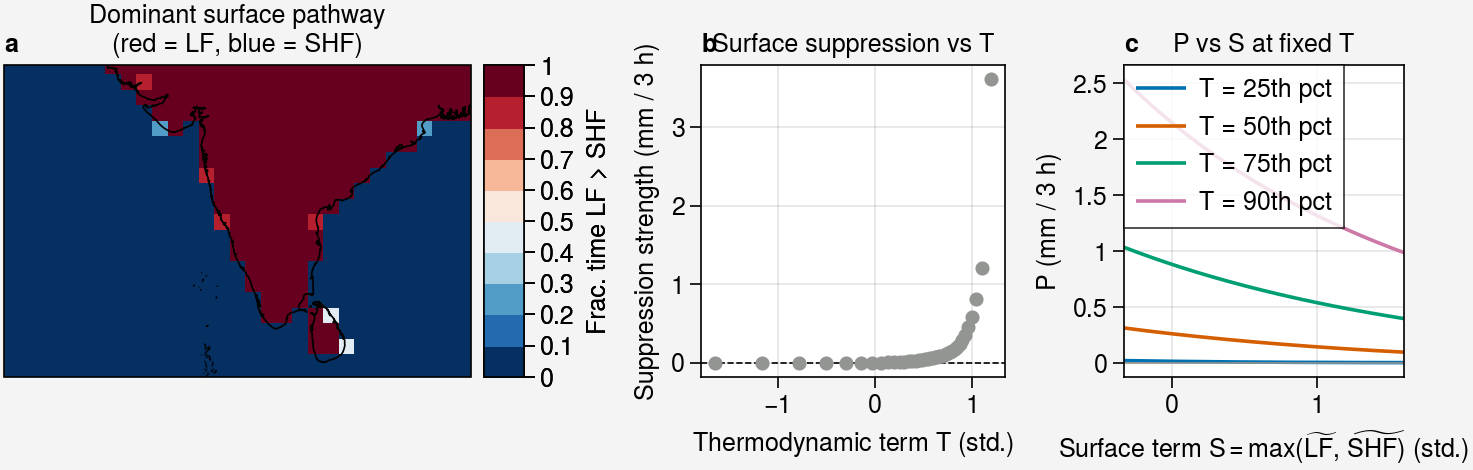

Suppressive term: d_h = -0.1271  (negative → S suppresses precipitation)
LF > SHF fraction: 30.2%


In [8]:
# ── Fig B: SR-HI  geographic + suppression + partial dependence (3-panel) ────
if 'sr_hi' not in SR_REGISTRY or shf_norm is None or lf_norm is None:
    print('sr_hi not in registry or surface vars missing — skipping')
else:
    _c = SR_REGISTRY['sr_hi']['constants']
    a_h, b_h, c_h, d_h = _c['a'], _c['b'], _c['c'], _c['d']

    M_hi = rh_k[valid]; I_hi = thetae_k[valid] + b_h*thetaestar_k[valid] + c_h
    T    = np.maximum(M_hi, I_hi)
    S    = np.maximum(lf_norm[valid], shf_norm[valid])
    P    = true_flat[valid]

    T_lo, T_hi = prange(T); S_lo, S_hi = prange(S)

    # (a) geographic surface pathway dominance
    lf_dom_2d = (lf_norm.reshape(refshape) > shf_norm.reshape(refshape)).mean(axis=0)
    latlim = (float(lats.min()), float(lats.max()))
    lonlim = (float(lons.min()), float(lons.max()))

    # (b) suppression strength vs thermodynamic favorability T
    supp = to_phys((a_h*T)**3) - to_phys((a_h*T + d_h*S)**3)
    _, T_cen, supp_means, _ = bin1d(T, supp)

    # (c) partial dependence P vs S at fixed T percentiles
    S_sw    = np.linspace(S_lo, S_hi, 200)
    T_pcts  = [25, 50, 75, 90]
    T_fixed = np.percentile(T, T_pcts)
    _ylabel_S = r'Surface term $S = \max(\widetilde{LF},\,\widetilde{SHF})$ (std.)'

    fig, axs = pplt.subplots(ncols=3, figwidth=7.5, wratios=(2, 1.3, 1.2),
                              proj={1:'cyl'}, share=False)
    kw_map = dict(coast=True, lonlim=lonlim, latlim=latlim, grid=False)

    # (a) geographic LF vs SHF dominance
    m0 = axs[0].pcolormesh(lons, lats, lf_dom_2d, cmap='RdBu_r', vmin=0, vmax=1)
    axs[0].format(title='Dominant surface pathway\n(red = LF, blue = SHF)', **kw_map)
    fig.colorbar(m0, ax=axs[0], loc='b', label='Frac. time LF > SHF')

    # (b) suppression strength vs T
    axs[1].scatter(T_cen, supp_means, color='gray', s=20, zorder=4)
    axs[1].axhline(0, color='k', lw=0.6, ls='--')
    axs[1].format(xlabel=r'Thermodynamic term $T$ (std.)',
                  ylabel='Suppression strength (mm / 3 h)',
                  title='Surface suppression vs T')

    # (c) partial dependence P vs S at fixed T
    for perc, tv in zip(T_pcts, T_fixed):
        P_sw = to_phys((a_h*tv + d_h*S_sw)**3)
        axs[2].plot(S_sw, P_sw, label=f'T = {perc}th pct', lw=1.3)
    axs[2].axhline(0, color='gray', lw=0.6)
    axs[2].format(xlabel=_ylabel_S, ylabel='P (mm / 3 h)',
                  title=r'P vs $S$ at fixed $T$')
    axs[2].legend(loc='ul', ncols=1, fontsize=7)

    fig.format(abc=True)
    pplt.show()
    fig.save('../figs/fig_srhi.pdf'); fig.save('../figs/fig_srhi.png')
    print(f'Suppressive term: d_h = {d_h:.4f}  (negative → S suppresses precipitation)')
    print(f'LF > SHF fraction: {(lf_norm[valid]>shf_norm[valid]).mean():.1%}')

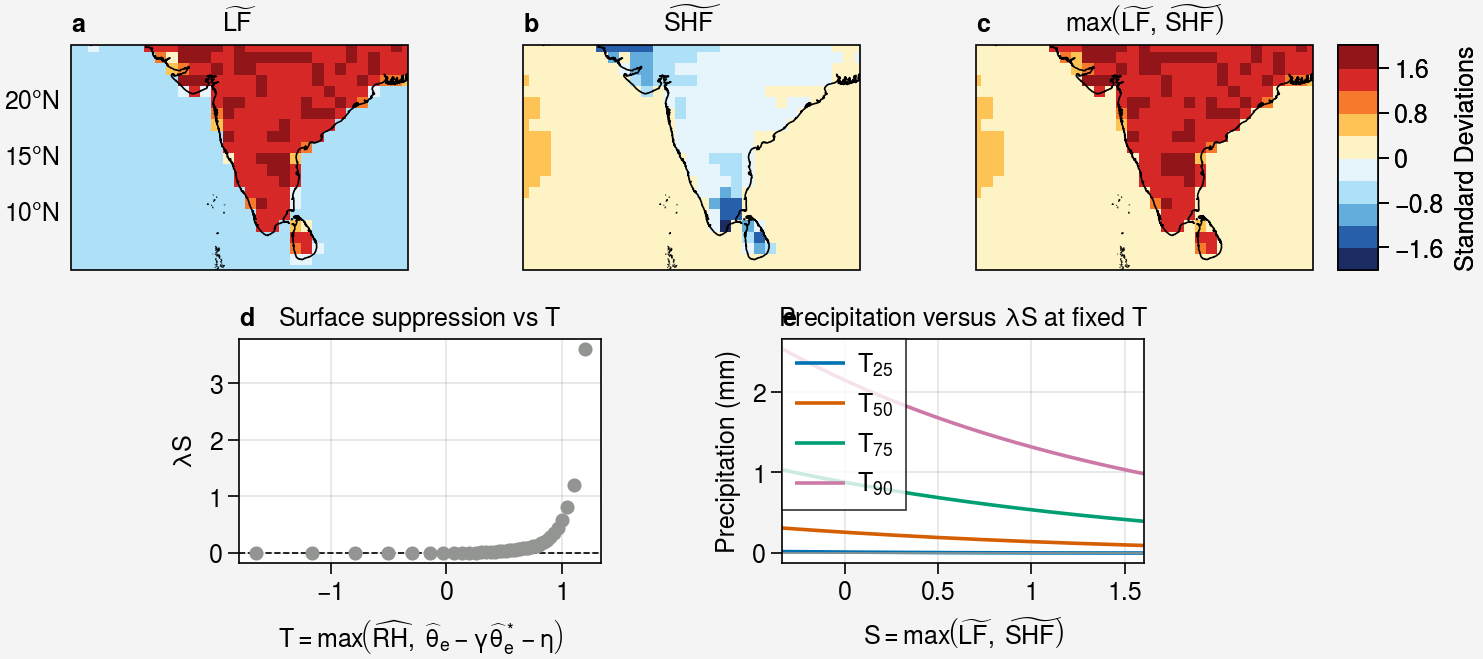

Suppressive term: d_h = -0.1271  (negative → S suppresses precipitation)
LF > SHF fraction: 30.2%


In [74]:
# ── Fig B: SR-HI  surface fields + suppression + partial dependence ──────────
if 'sr_hi' not in SR_REGISTRY or shf_norm is None or lf_norm is None:
    print('sr_hi not in registry or surface vars missing — skipping')
else:
    _c = SR_REGISTRY['sr_hi']['constants']
    a_h, b_h, c_h, d_h = _c['a'], _c['b'], _c['c'], _c['d']

    M_hi = rh_k[valid]; I_hi = thetae_k[valid] + b_h*thetaestar_k[valid] + c_h
    T    = np.maximum(M_hi, I_hi)
    S    = np.maximum(lf_norm[valid], shf_norm[valid])
    P    = true_flat[valid]

    T_lo, T_hi = prange(T); S_lo, S_hi = prange(S)
    latlim = (float(lats.min()), float(lats.max()))
    lonlim = (float(lons.min()), float(lons.max()))

    # geographic mean surface fields
    lf_mean_2d  = lf_norm.reshape(refshape).mean(axis=0)
    shf_mean_2d = shf_norm.reshape(refshape).mean(axis=0)
    max_mean_2d = np.maximum(lf_norm, shf_norm).reshape(refshape).mean(axis=0)
    climlim     = float(np.nanmax(np.abs([lf_mean_2d, shf_mean_2d, max_mean_2d])))

    # suppression strength vs T
    supp = to_phys((a_h*T)**3) - to_phys((a_h*T + d_h*S)**3)
    _, T_cen, supp_means, _ = bin1d(T, supp)

    # partial dependence P vs S at fixed T percentiles
    S_sw    = np.linspace(S_lo, S_hi, 200)
    T_pcts  = [25, 50, 75, 90]
    T_fixed = np.percentile(T, T_pcts)

    _label_T = r'$T = \max\!\left(\widehat{\mathrm{RH}},\;\widehat{\theta}_e - \gamma\widehat{\theta}_e^* - \eta\right)$'
    _label_S = r'$S = \max\!\left(\widetilde{\mathrm{LF}},\;\widetilde{\mathrm{SHF}}\right)$'

    fig, axs = pplt.subplots([[1,1,2,2,3,3],[0,4,4,5,5,0]], figwidth=7.5,
                              proj={1:'cyl', 2:'cyl', 3:'cyl'}, share=False)
    kw_map = dict(coast=True, lonlim=lonlim, latlim=latlim,
                  lonlines=5, latlines=[10,15,20], grid=False)
    kw_sfc = dict(cmap='ColdHot', vmin=-climlim, vmax=climlim)

    ms = axs[0].pcolormesh(lons, lats, lf_mean_2d, **kw_sfc)
    axs[1].pcolormesh(lons, lats, shf_mean_2d, **kw_sfc)
    axs[2].pcolormesh(lons, lats, max_mean_2d, **kw_sfc)
    axs[0].format(title=r'$\widetilde{\mathrm{LF}}$', latlabels='l', **kw_map)
    axs[1].format(title=r'$\widetilde{\mathrm{SHF}}$', **kw_map)
    axs[2].format(title=r'$\max\!\left(\widetilde{\mathrm{LF}},\,\widetilde{\mathrm{SHF}}\right)$', **kw_map)
    fig.colorbar(ms, rows=1,  label='Standard Deviations')

    axs[3].scatter(T_cen, supp_means, color='gray', s=20, zorder=4)
    axs[3].axhline(0, color='k', lw=0.6, ls='--')
    axs[3].format(xlabel=_label_T, ylabel='$\lambda$S',
                  title='Surface suppression vs $T$')

    for perc, tv in zip(T_pcts, T_fixed):
        P_sw = to_phys((a_h*tv + d_h*S_sw)**3)
        axs[4].plot(S_sw, P_sw, label=f'$T_{{\\mathrm{{{perc}}}}}$', lw=1.3)
    axs[4].axhline(0, color='gray', lw=0.6)
    axs[4].format(xlabel=_label_S, ylabel='Precipitation (mm)', title='Precipitation versus $\lambda$S at fixed T')
    axs[4].legend(loc='ul', ncols=1, fontsize=7)

    fig.format(abc=True)
    pplt.show()
    fig.save('../figs/fig_srhi.png')

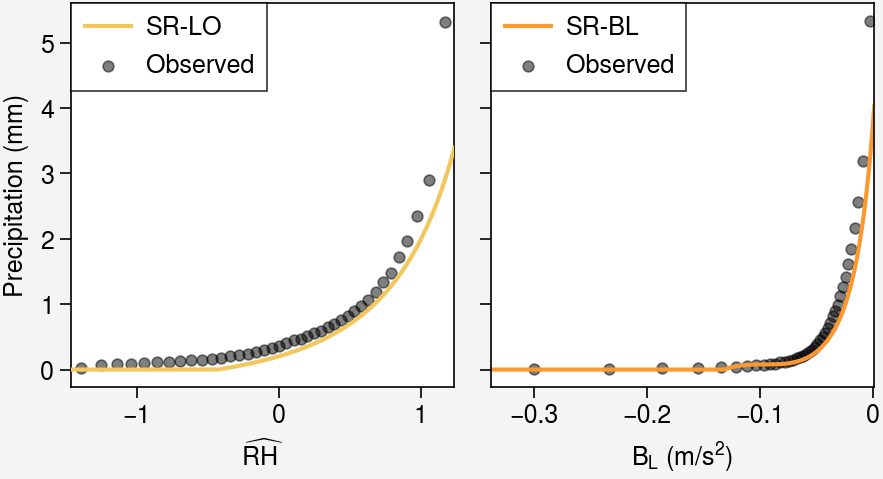

In [64]:
if 'sr_bl' not in SR_REGISTRY or bl_norm is None:
    print('sr_bl not in registry or bl unavailable — skipping')
else:
    _c = SR_REGISTRY['sr_bl']['constants']
    a_bl, b_bl = _c['a'], _c['b']
    bl_std = float(STATS.get('bl_std', 1.0)); bl_mean = float(STATS.get('bl_mean', 0.0))
    bl_v     = bl_norm[valid]; P_v = true_flat[valid]
    bl_nat_v = bl_v * bl_std + bl_mean
    bl_lo, bl_hi  = prange(bl_nat_v)
    bl_sw_nat     = np.linspace(bl_lo, bl_hi, 400)
    bl_sw_nrm     = (bl_sw_nat - bl_mean) / bl_std
    P_srbl        = to_phys((bl_sw_nrm + a_bl)**3 + b_bl)
    _, bl_cen, bl_obs_means, _ = bin1d(bl_nat_v, P_v)

    fig,axs = pplt.subplots(ncols=2,figwidth=4.5,sharex=False,sharey=True)
    axs[0].scatter(rh_cen, rh_obs_means, color='k', alpha=0.5,s=15, zorder=0, label='Observed')
    axs[0].plot(rh_sw, P_lo, color=COLORS['sr_lo'], lw=1.5, zorder=5, label=LABELS['sr_lo'])
    axs[0].format(xlabel=r'$\widehat{\mathrm{RH}}$',xlim=(rh_lo,rh_hi))
    axs[0].legend(loc='ul',ncols=1)
    axs[1].scatter(bl_cen, bl_obs_means, color='k', alpha=0.5,s=15, zorder=0, label='Observed')
    axs[1].plot(bl_sw_nat, P_srbl, color=COLORS['sr_bl'], lw=1.5, label=LABELS['sr_bl'])
    axs[1].format(xlabel=r'$B_L$ (m/s$^2$)',xlim=(bl_lo, bl_hi))
    axs[1].legend(loc='ul',ncols=1)
    axs.format(grid=False,ylabel='Precipitation (mm)')
    pplt.show()
    fig.save('../figs/fig_srbl.jpg')